# Project Overview: Binary Image Classification for Wildfire Detection
**Objective:** To classify environmental imagery for real-time wildfire and smoke detection, focusing on mitigating severe class imbalance through proportional dataset partitioning and dynamic loss adjustments to minimize validation errors and maximize the final Test Accuracy metric.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('image-detection-for-fires')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/image-detection-for-fires


In [2]:
import cv2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
from sklearn.model_selection import train_test_split
from keras.models import Sequential
import tensorflow as tf
from keras.layers import Input, Conv2D, Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import FileLink
from sklearn.metrics import classification_report, confusion_matrix
import random
import matplotlib.image as mpimg
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score



2026-05-18 00:37:09.758130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779064630.228678      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779064630.386647      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779064631.573675      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779064631.573714      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779064631.573717      57 computation_placer.cc:177] computation placer alr

## 2. Data & Visual Integrity Verification

In [3]:
path = '/kaggle/input/competitions/image-detection-for-fires/'

In [4]:
os.listdir(path)

['sample_submission.csv', 'test', 'train']

In [5]:
img_path = '/kaggle/input/competitions/image-detection-for-fires/train/'

In [6]:
os.listdir(img_path)

['0', '1']

In [7]:
labels=['0', '1',]

In [8]:
img_list=[]
label_list=[]
for label in labels:
  for img_file in os.listdir(img_path+label):
    img_list.append(img_path+'/'+label)
    label_list.append(label)

In [9]:
df=pd.DataFrame({'img':img_list, 'label':label_list})

In [10]:
df

,img,label
0,/kaggle/input/competitions/image-detection-for...,0
1,/kaggle/input/competitions/image-detection-for...,0
2,/kaggle/input/competitions/image-detection-for...,0
3,/kaggle/input/competitions/image-detection-for...,0
4,/kaggle/input/competitions/image-detection-for...,0
...,...,...
694,/kaggle/input/competitions/image-detection-for...,1
695,/kaggle/input/competitions/image-detection-for...,1
696,/kaggle/input/competitions/image-detection-for...,1
697,/kaggle/input/competitions/image-detection-for...,1


/tmp/ipykernel_57/688586399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


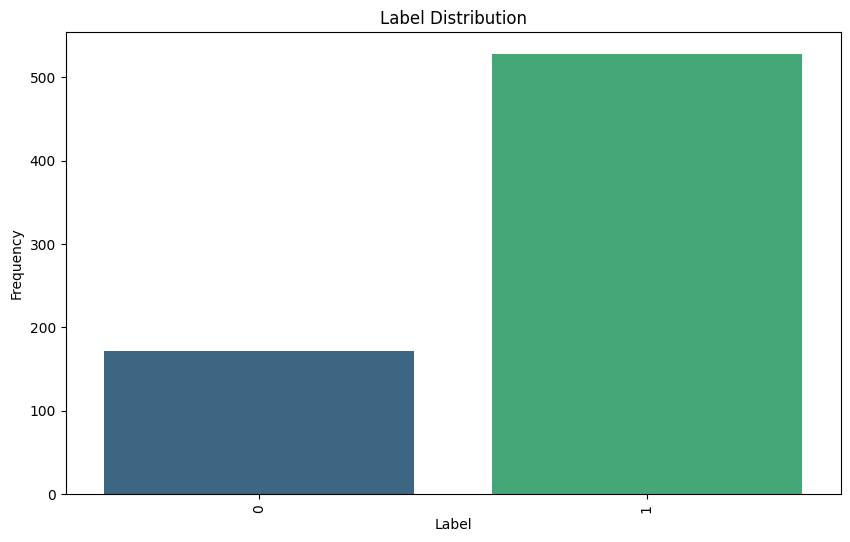

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show();

In [12]:
classes = os.listdir(img_path)

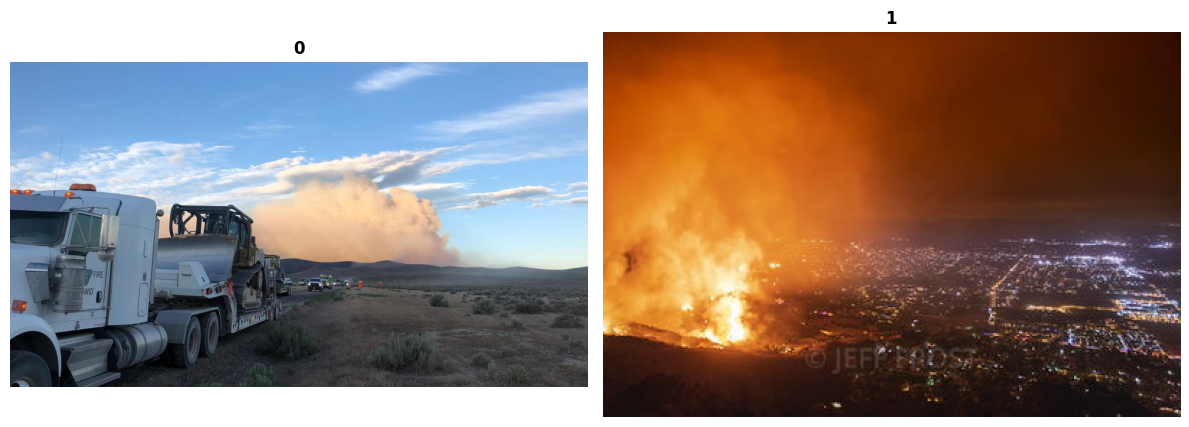

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    if i < len(axes):
        class_folder_path = os.path.join(img_path, class_name)
        
        image_name = random.choice(os.listdir(class_folder_path))
        full_image_path = os.path.join(class_folder_path, image_name)
        
        img = cv2.imread(full_image_path)
        
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(img)
            axes[i].set_title(class_name, fontsize=12, fontweight='bold')
        else:
            axes[i].set_title(f"{class_name}\n(Unreadable Image)", color='red')
            
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [14]:
x = []

paths = glob.glob('/kaggle/input/competitions/image-detection-for-fires/train/*/*')

for path in paths:
    # Read the image directly
    img = cv2.imread(path)
    
    # Process without any conditional checks
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0
    
    x.append(img)

In [15]:
x=np.array(x)

In [16]:
x.shape

(699, 128, 128, 3)

In [17]:
y=df[['label']]

In [18]:
y.shape

(699, 1)

In [19]:
y=np.array(y, dtype=np.int32)

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42, stratify=df["label"], test_size=.20)

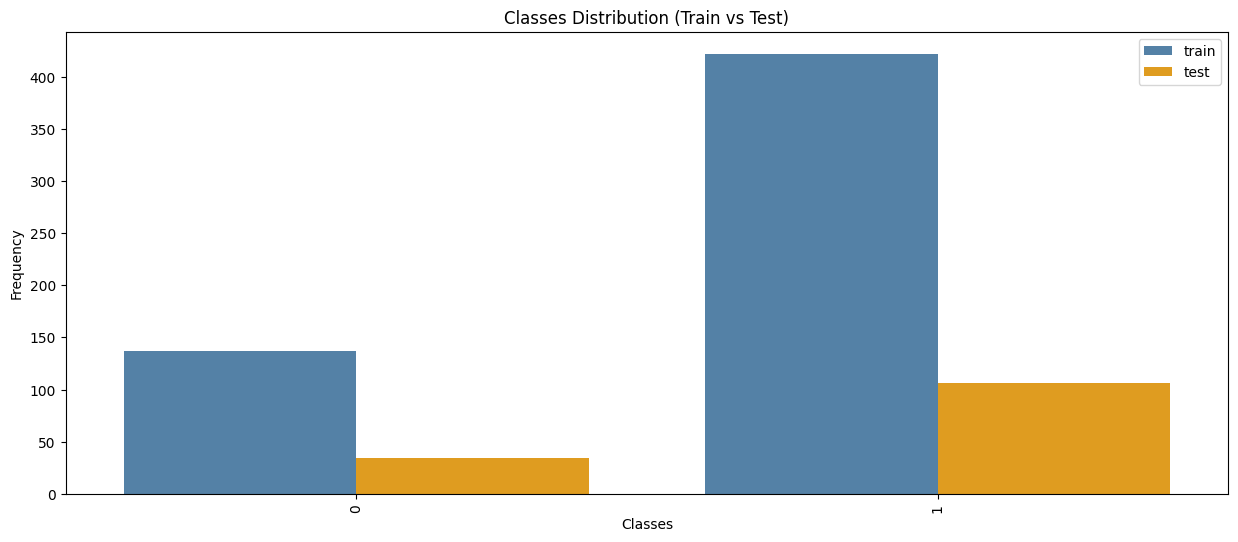

In [21]:
y_train_flat = np.array(y_train).flatten()
y_test_flat = np.array(y_test).flatten()

df_train = pd.DataFrame({'Label': y_train_flat, 'Dataset': 'train'})
df_test = pd.DataFrame({'Label': y_test_flat, 'Dataset': 'test'})
df_combined = pd.concat([df_train, df_test])

plt.figure(figsize=(15, 6))

sns.countplot(data=df_combined, x='Label', hue='Dataset', palette=['steelblue', 'orange'])

plt.xticks(rotation=90)
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.title('Classes Distribution (Train vs Test)')
plt.legend()
plt.show()

In [22]:
y_train_flat = np.array(y_train).flatten()

unique_classes = np.unique(y_train_flat)

class_weights = compute_class_weight(
    class_weight="balanced", classes=unique_classes, y=y_train_flat
)

class_weight_dict = dict(zip(unique_classes.tolist(), class_weights))

# Output the calculated weights to verify
print(f"Calculated Class Weights: {class_weight_dict}")

Calculated Class Weights: {0: np.float64(2.04014598540146), 1: np.float64(0.6623222748815166)}


## 3. Neural Network Architecture

In [23]:
model = Sequential(
    [
        Input(shape=(128, 128, 3)),
        
        Conv2D(32, (3, 3), padding="same", kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        shape=(224, 224, 3)(alpha=0.1),
        MaxPooling2D(2, 2),
        Dropout(0.3),
        
        Conv2D(64, (3, 3), padding="same", kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        MaxPooling2D(2, 2),
        Dropout(0.4),
        
        Conv2D(128, (3, 3), padding="same", kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        MaxPooling2D(2, 2),
        Dropout(0.4),
        
        Flatten(),
        Dense(128),  
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.5),
        # Output Layer
        Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer=Adam(learning_rate=0.00005), loss="binary_crossentropy", metrics=["accuracy"],)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
2026-05-18 00:38:17.233278: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [24]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, verbose=1, restore_best_weights=True)

## 4. Model Training & Convergence Performance

In [25]:
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5122 - loss: 0.9326 - val_accuracy: 0.7571 - val_loss: 0.7129
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7910 - loss: 0.6051 - val_accuracy: 0.7571 - val_loss: 0.6579
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7890 - loss: 0.5589 - val_accuracy: 0.7571 - val_loss: 0.6548
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8195 - loss: 0.5047 - val_accuracy: 0.7571 - val_loss: 0.6588
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8208 - loss: 0.4439 - val_accuracy: 0.7571 - val_loss: 0.6648
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8928 - loss: 0.3962 - val_accuracy: 0.7571 - val_loss: 0.6710
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9017 - loss: 0.3593 - val_accuracy: 0.7571 - val_loss: 0.6804
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8735 - loss: 0.3814 - val_accuracy: 0.7571 - val_loss: 0.6808


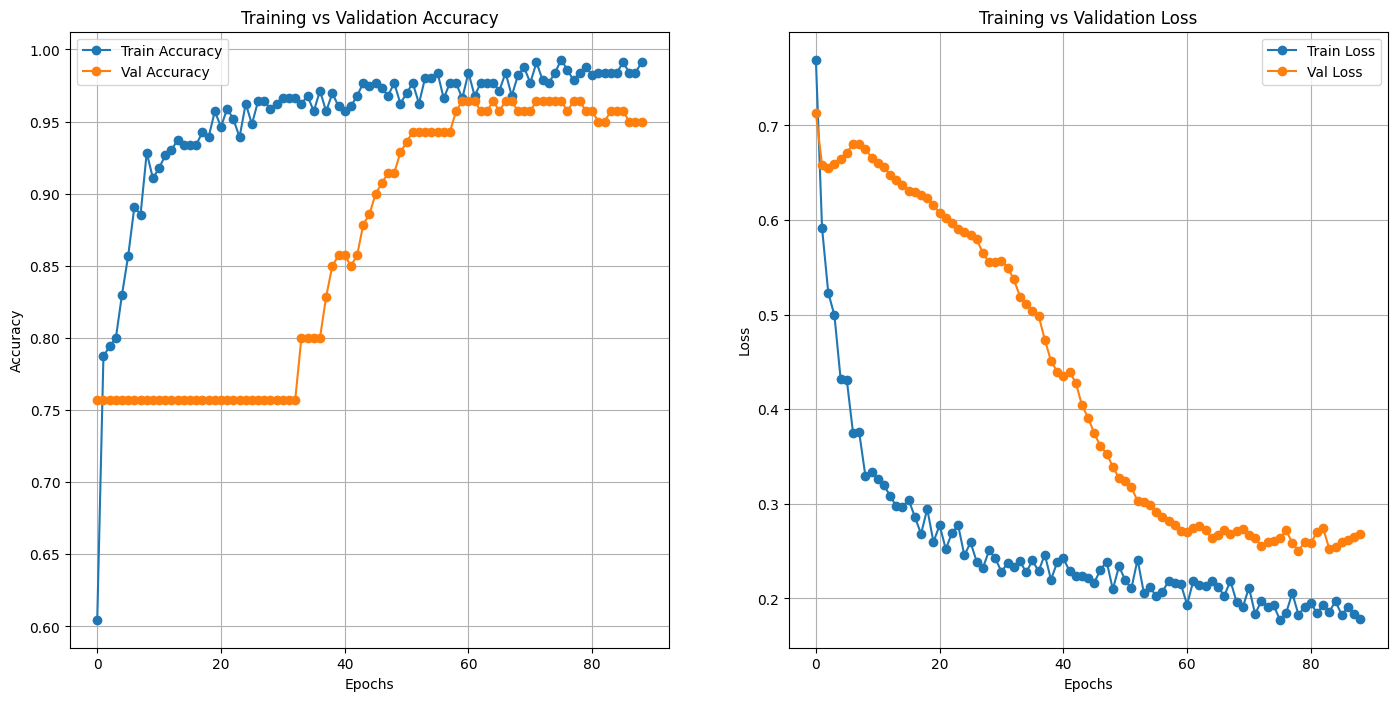

In [26]:
plt.figure(figsize=(17, 8))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss 
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [31]:
model.save('fire.h5')
display(FileLink('fire.h5'))

/kaggle/working/fire.h5

In [27]:
y_pred_probs = model.predict(x_test)

threshold = 0.5 if (y_pred_probs.min() < 0.4 and y_pred_probs.max() > 0.6) else np.mean(y_pred_probs)
print(f"The threshold value used in the calculation is: {threshold:.4f}")

y_pred_classes = (y_pred_probs >= threshold).astype(int).flatten()
y_test_flattened = np.array(y_test).flatten()

incorrect_prediction_count = np.sum(y_pred_classes != y_test_flattened)
error_rate = (incorrect_prediction_count / len(y_test_flattened)) * 100
calculated_accuracy = accuracy_score(y_test_flattened, y_pred_classes)

print(f"Number of incorrect predictions: {incorrect_prediction_count}")
print(f"Error rate: {error_rate:.2f}%")
print(f"Calculated Test Accuracy: {calculated_accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
The threshold value used in the calculation is: 0.5000
Number of incorrect predictions: 5
Error rate: 3.57%
Calculated Test Accuracy: 96.43%


## 5. Final Performance Evaluation & Diagnostics

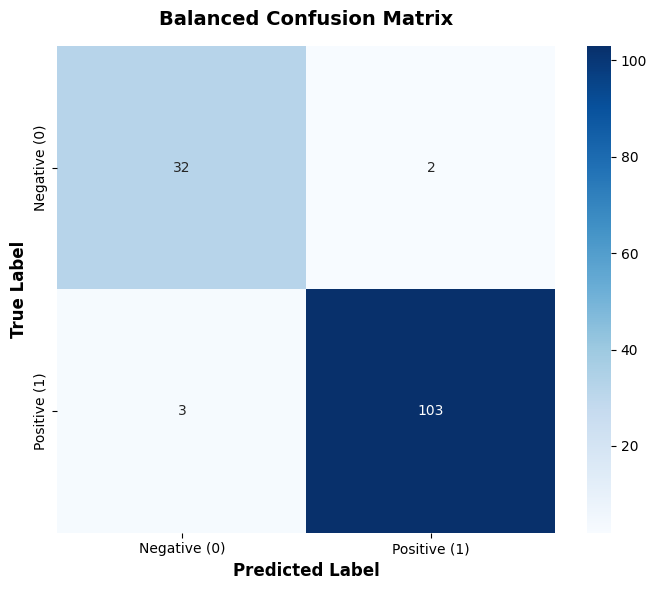

In [28]:
cm = confusion_matrix(y_test_flattened, y_pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
)

plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("True Label", fontsize=12, fontweight="bold")
plt.title("Balanced Confusion Matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

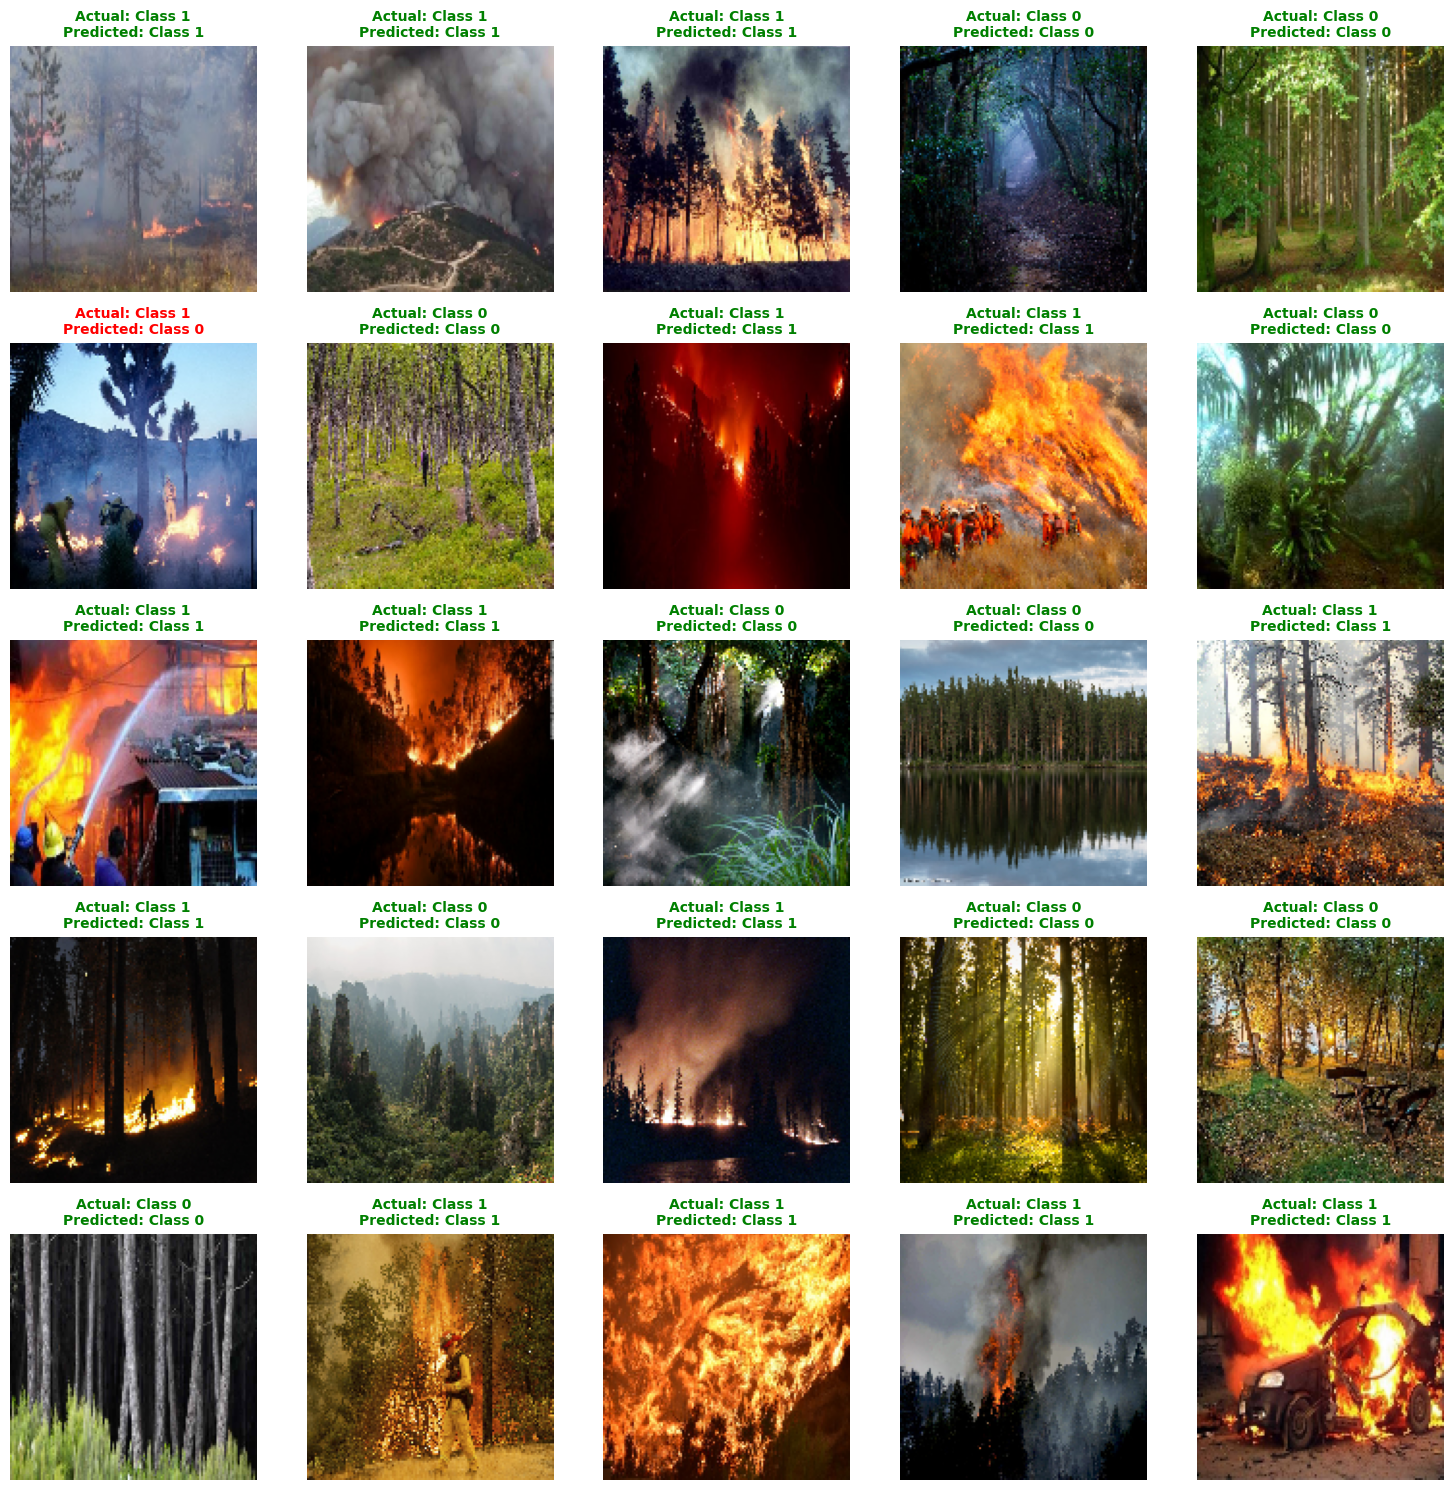

In [29]:
num_samples = len(x_test)
n_images = 25
random_indices = np.random.choice(num_samples, size=n_images, replace=False)

x_test_sample = x_test[random_indices]
y_test_array = np.array(y_test).flatten()
actual_labels = y_test_array[random_indices]

sample_predictions = y_pred_probs[random_indices]

predicted_labels = (sample_predictions >= threshold).astype(int).flatten()

binary_label_map = {0: "Class 0", 1: "Class 1"}

plt.figure(figsize=(15, 15))

for i in range(n_images):
    plt.subplot(5, 5, i + 1)

    plt.imshow(x_test_sample[i])

    actual_name = binary_label_map.get(
        actual_labels[i], f"Class {actual_labels[i]}"
    )
    predicted_name = binary_label_map.get(
        predicted_labels[i], f"Class {predicted_labels[i]}"
    )

    color = "green" if actual_labels[i] == predicted_labels[i] else "red"

    plt.title(
        f"Actual: {actual_name}\nPredicted: {predicted_name}",
        fontsize=10,
        color=color,
        fontweight="bold",
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

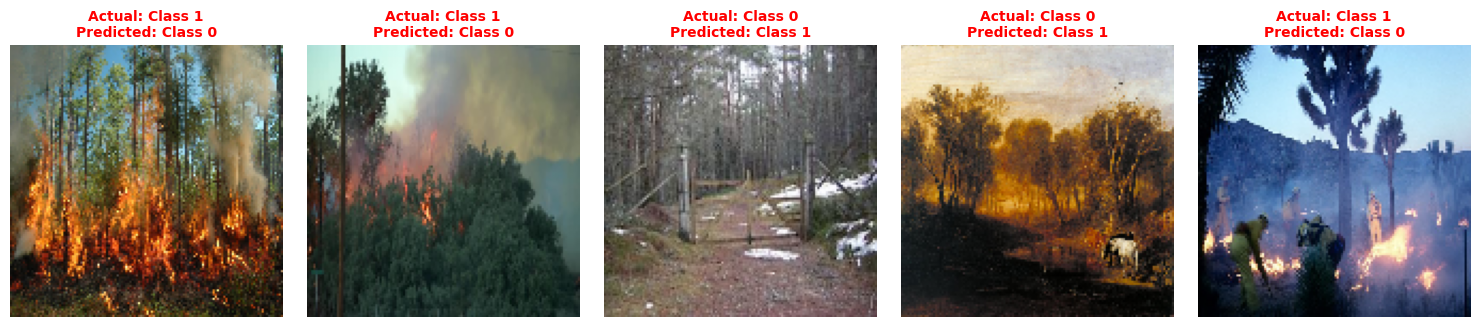

In [30]:
error_indexes = np.where(y_pred_classes != y_test_flattened)[0]

binary_label_map = {0: "Class 0", 1: "Class 1"}

if len(error_indexes) > 0:
    plt.figure(figsize=(15, 12))

    for i, index in enumerate(error_indexes[:20]):
        plt.subplot(4, 5, i + 1)

        plt.imshow(x_test[index])

        actual_label_val = y_test_flattened[index]
        predicted_label_val = y_pred_classes[index]

        actual_name = binary_label_map.get(
            actual_label_val, f"Class {actual_label_val}"
        )
        predicted_name = binary_label_map.get(
            predicted_label_val, f"Class {predicted_label_val}"
        )

        plt.title(
            f"Actual: {actual_name}\nPredicted: {predicted_name}",
            color="red",
            fontsize=10,
            fontweight="bold",
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()